In [1]:
import xarray as xr
import rioxarray as rxr
from pyproj import Transformer
import tensorflow as tf
import numpy as np
import glob
import re
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from utils import retrieve_url, str2time
from data_funcs import int2fstep

In [2]:
static_files = ["hrrr_elevs.608.tif", "hrrr_lons.pkl", "hrrr_lats.pkl"]
base_url = "https://demo.openwfm.org/web/data/fmda/tif"
data_path = "."

In [3]:
for file in static_files:
    retrieve_url(
        f"{base_url}/{file}",
        f"{data_path}/{file}"
    )    

Target data already exists at ./hrrr_elevs.608.tif
Target data already exists at ./hrrr_lons.pkl
Target data already exists at ./hrrr_lats.pkl


In [4]:
elev = xr.open_dataset("hrrr_elevs.608.tif")

In [5]:
import sys
sys.path.append("..")
from utils import read_pkl

In [6]:
lats = read_pkl("hrrr_lats.pkl")
lons = read_pkl("hrrr_lons.pkl")

loading file hrrr_lats.pkl
loading file hrrr_lons.pkl


In [7]:
lats.shape

(1059, 1799)

In [8]:
elev

<xarray.Dataset>
Dimensions:      (band: 1, x: 1799, y: 1059)
Coordinates:
  * band         (band) int64 1
  * x            (x) float64 -2.698e+06 -2.695e+06 ... 2.693e+06 2.696e+06
  * y            (y) float64 1.587e+06 1.584e+06 ... -1.584e+06 -1.587e+06
    spatial_ref  int64 ...
Data variables:
    band_data    (band, y, x) float64 ...

In [9]:
elev.band_data

<xarray.DataArray 'band_data' (band: 1, y: 1059, x: 1799)>
[1905141 values with dtype=float64]
Coordinates:
  * band         (band) int64 1
  * x            (x) float64 -2.698e+06 -2.695e+06 ... 2.693e+06 2.696e+06
  * y            (y) float64 1.587e+06 1.584e+06 ... -1.584e+06 -1.587e+06
    spatial_ref  int64 ...
Attributes:
    AREA_OR_POINT:  Area

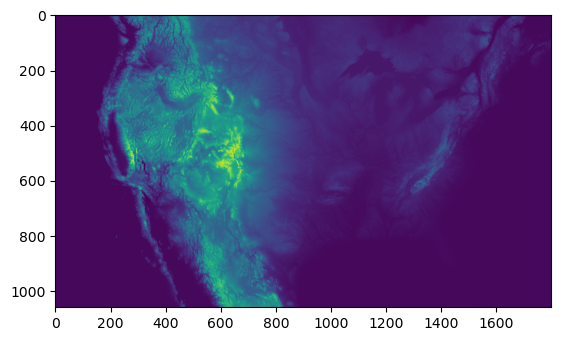

In [10]:
plt.imshow(elev.isel(band=0).band_data)

In [11]:
from utils import read_yml
from data_funcs import build_train_dict, combine_nested

In [12]:
# Params used for data filtering
params_data = read_yml("../params_data.yaml") 
params_data.update({
    'hours': None,
    'max_intp_time': 10000,
    'zero_lag_threshold':10000
})
feats = ['Ed', 'Ew', 'rain', 'wind', 'solar', 'elev', 'lat', 'lon']

filename = "fmda_rocky_202403-05_f05.pkl"
file_paths = [f'../data/{filename}']
train = build_train_dict(file_paths, atm_source="HRRR", params_data = params_data,
                         features_subset = feats, spatial=False, verbose=True)
# train = subset_by_features(train, params['features_list'])
train = combine_nested(train)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Extracting data from input file ../data/fmda_rocky_202403-05_f05.pkl
loading file ../data/fmda_rocky_202403-05_f05.pkl
Shifted time based on forecast step 3. Dropping NA at beginning of feature data and corresponding times of output data
Shifted time based on forecast step 3. Dropping NA at beginning of feature data and corresponding times of output data
Shifted time based on forecast step 3. Dropping NA at beginning of feature data and corresponding times of output data
Shifted time based on forecast step 3. Dropping NA at beginning of feature data and corresponding times of output data
Shifted time based on forecast step 3. Dropping NA at beginning of feature data and corresponding times of output data
Shifted time based on forecast step 3. Dropping NA at beginning of feature data and corresponding times of output data
Shifted time based on forecast step 3. Dropping NA at beginning of feature data and corresp

In [13]:
train.keys()

dict_keys(['id', 'case', 'filename', 'time', 'X', 'y', 'atm_source', 'forecast_step', 'loc', 'features_list'])

In [14]:
train['loc'].keys()

dict_keys(['STID', 'lat', 'lon', 'elev', 'pixel_x', 'pixel_y'])

In [15]:
import importlib
import data_funcs
importlib.reload(data_funcs)
from data_funcs import dict_to_df

In [16]:
loc = dict_to_df(train['loc'])

In [17]:
loc

,STID,lat,lon,elev,pixel_x,pixel_y
0,CPTC2,38.45964,-109.04731,8124,565.395322,509.897014
1,CHAC2,37.19944,-108.48917,7126,575.909481,558.257886
2,CHRC2,39.18139,-105.26722,7546,676.755073,494.729083
3,DYKC2,37.22694,-107.30528,7460,610.757692,561.185251
4,LKGC2,38.97861,-105.35444,8094,673.617234,502.005996
...,...,...,...,...,...,...
124,TT788,40.07733,-105.10181,5090,684.231701,462.022660
125,TT789,40.17480,-105.30242,6730,678.865724,457.945558
126,TT813,43.91461,-109.00789,7610,591.783773,309.119821
127,TT815,37.49950,-108.35903,7975,581.035201,547.665953


In [18]:
ds = rxr.open_rasterio("hrrr_elevs.608.tif")

In [19]:
type(ds)

xarray.core.dataarray.DataArray

In [20]:
from moisture_rnn_xarray import lonlat_to_xy, xy_to_grid, xr_to_lonlat

In [21]:
x, y = lonlat_to_xy(loc.lat, loc.lon, ds.rio.crs)

In [22]:
ds

<xarray.DataArray (band: 1, y: 1059, x: 1799)>
[1905141 values with dtype=float64]
Coordinates:
  * band         (band) int64 1
  * x            (x) float64 -2.698e+06 -2.695e+06 ... 2.693e+06 2.696e+06
  * y            (y) float64 1.587e+06 1.584e+06 ... -1.584e+06 -1.587e+06
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [23]:
grid_x, grid_y = xy_to_grid(x, y, ds)

In [24]:
grid_x

array([565.39532188, 575.90948079, 676.75507344, 610.75769185,
       673.61723422, 707.83453769, 648.4852945 , 673.25347297,
       576.51056419, 679.22018813, 566.36332428, 521.11478998,
       539.22196962, 715.9198223 , 545.38161465, 658.60313899,
       647.26774755, 672.13762776, 578.57831798, 671.73641743,
       527.12430084, 539.60185197, 581.14543745, 680.47724056,
       675.34362098, 676.70510058, 669.98557244, 672.13955887,
       675.56078606, 640.76829581, 588.3514244 , 552.25821475,
       579.12195256, 565.51234451, 640.0626639 , 585.54548121,
       621.25075483, 822.0031356 , 750.35258338, 728.04650012,
       741.00268565, 735.68308734, 734.73949634, 739.22710518,
       730.67498382, 926.94914539, 871.15124804, 762.99034477,
       816.84833386, 663.70472905, 672.03017449, 769.63628867,
       900.95468877, 547.09692879, 939.03573981, 684.49679078,
       617.92401643, 562.70178622, 602.60953491, 772.57572841,
       708.16039368, 568.54624647, 865.56384585, 865.77

In [25]:
loc.pixel_x

0      565.395322
1      575.909481
2      676.755073
3      610.757692
4      673.617234
          ...    
124    684.231701
125    678.865724
126    591.783773
127    581.035201
128    714.143606
Name: pixel_x, Length: 129, dtype: float64

In [26]:
np.max(np.abs(grid_x - loc.pixel_x))

2.2737367544323206e-13

In [27]:
type(lats)

numpy.ndarray

In [28]:
type(lons)

numpy.ndarray

In [29]:
lonlat = xr_to_lonlat(ds)

In [30]:
lons2 = lonlat[0]
lats2 = lonlat[1]

In [31]:
np.max(np.abs(lons2-lons))

0.025948973129743536

In [32]:
loc

,STID,lat,lon,elev,pixel_x,pixel_y
0,CPTC2,38.45964,-109.04731,8124,565.395322,509.897014
1,CHAC2,37.19944,-108.48917,7126,575.909481,558.257886
2,CHRC2,39.18139,-105.26722,7546,676.755073,494.729083
3,DYKC2,37.22694,-107.30528,7460,610.757692,561.185251
4,LKGC2,38.97861,-105.35444,8094,673.617234,502.005996
...,...,...,...,...,...,...
124,TT788,40.07733,-105.10181,5090,684.231701,462.022660
125,TT789,40.17480,-105.30242,6730,678.865724,457.945558
126,TT813,43.91461,-109.00789,7610,591.783773,309.119821
127,TT815,37.49950,-108.35903,7975,581.035201,547.665953


In [33]:
np.max(np.abs(grid_x - loc.pixel_x))

2.2737367544323206e-13

In [34]:
x

array([-1002834.1768735 ,  -971291.70014048,  -668754.92219034,
        -866747.06698425,  -678168.43986087,  -575516.52945464,
        -753564.25900825,  -679259.72360135,  -969488.44994294,
        -661359.57812184,  -999930.16968446, -1135675.77257744,
       -1081354.23365542,  -551260.67561349, -1062875.29858024,
        -723210.72555635,  -757216.89985881,  -682607.2592494 ,
        -963285.18858581,  -683810.89021897, -1117647.23999704,
       -1080214.58662056,  -955583.83016807,  -657588.42084558,
        -672989.27959212,  -668904.84077401,  -689063.42520208,
        -682601.46591273,  -672337.78435642,  -776715.25509741,
        -933965.86931457, -1042245.4982792 ,  -961654.28483521,
       -1002483.10900442,  -778832.15082914,  -942383.69888394,
        -835267.87802432,  -233010.73573516,  -447962.39238482,
        -514880.64216109,  -476012.08556817,  -491970.88050256,
        -494801.65349572,  -481338.82696894,  -506995.19105532,
          81827.29364788,   -85566.39839

In [35]:
# Extract the CRS from the xarray object
crs_xarray = ds.rio.crs

# Define the transformer for converting x/y to lat/lon
transformer = Transformer.from_crs(crs_xarray, "EPSG:4326", always_xy=True)


# Create a meshgrid of x and y coordinates
# xx, yy = np.meshgrid(x, y)

# Transform x/y to lon/lat
lon, lat = transformer.transform(x, y)

In [36]:
np.max(np.abs(lon-loc.lon))

1.4210854715202004e-14

In [37]:
lons.shape

(1059, 1799)

In [38]:
lats.shape

(1059, 1799)

In [39]:
lons2.shape

(1059, 1799)

In [40]:
lats.shape

(1059, 1799)

In [41]:
lons[0,0]

-134.12142793280145

In [42]:
lons2[0,0]

-134.09547973426314